In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [53]:
# **Index price** is a single value that represents the **overall performance of the market**.
# It shows how the **economy and companies** are performing together.
# Example: Sensex or NIFTY value is the **index price**.
# **Higher index price** means the market and economy are **strong and doing well**.

# **One-line:**
# > Index price = one number showing the market’s overall condition.

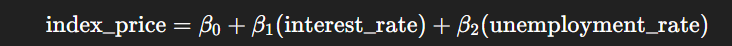

In [54]:
# DEPENDNENT FEATURES => interest_rate & unemployment_rate
# INDEPENDENT FEATURE => index_price

# This a MULTIPLE Linear Regression cause here we have more than 1 DEPENDENT FEATURES.

In [55]:
df_index = pd.read_csv("economic_index.csv")

In [56]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [57]:
# Drop un-necessary columns-:
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [58]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [59]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

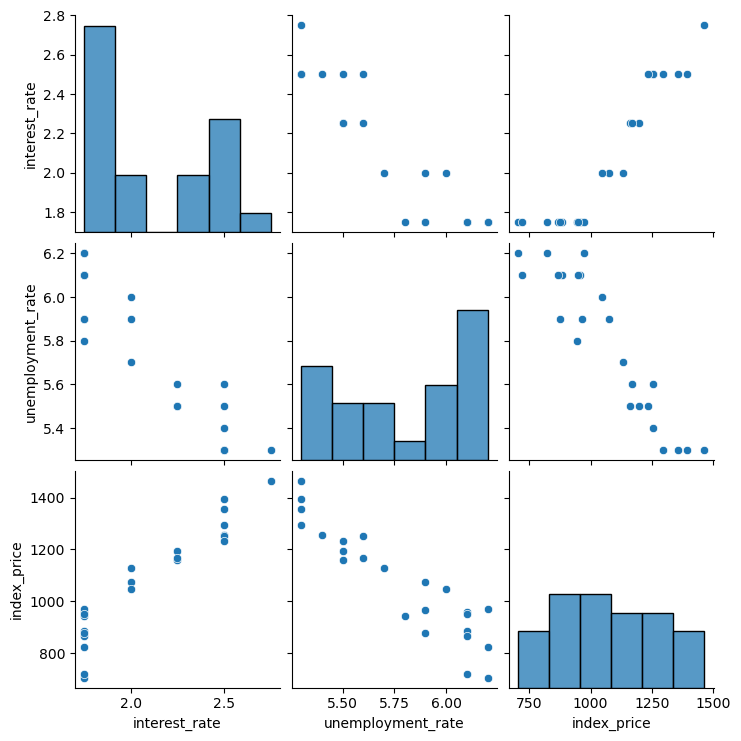

In [60]:
# VISUALIZATION-:
import seaborn as sns
sns.pairplot(df_index)

In [61]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

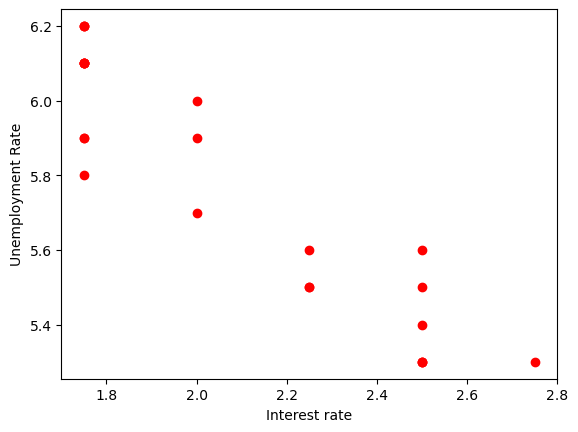

In [62]:
# Visualize the datapoints more clearly-:
plt.scatter(df_index['interest_rate'],df_index["unemployment_rate"],color='r')
plt.xlabel("Interest rate")
plt.ylabel("Unemployment Rate")

In [63]:
# independent and dependent features-:
X = df_index[['interest_rate','unemployment_rate']]
# another way-:
# df.loc[start_row : end_row, start_col : end_col]
# in loc both start and stop are included whereas in normal python slicing -: stop is excluded.
X = df_index.loc[:,:'unemployment_rate']

In [64]:
y = df_index.loc[:,"index_price"]

In [65]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [66]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [67]:
type(y)

pandas.core.series.Series

In [68]:
# train test split-:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

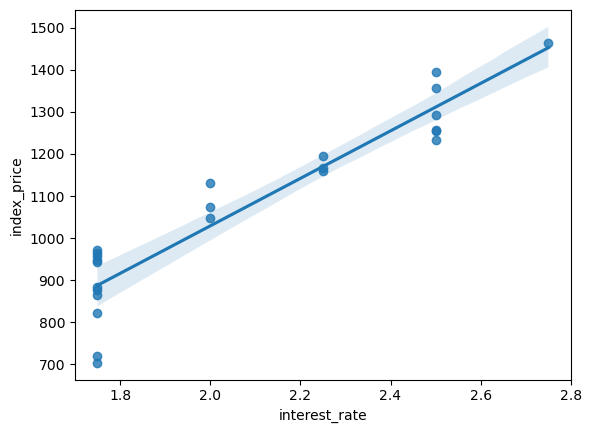

In [69]:
import seaborn as sns
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
# sns.regplot() automatically performs linear regression and plots both the data points and the best-fit regression line in one graph.
# In short, it does regression internally and visualizes it.

# The light blue area is the confidence interval around the regression line.
# It shows the uncertainty range where the true regression line is likely to lie.

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

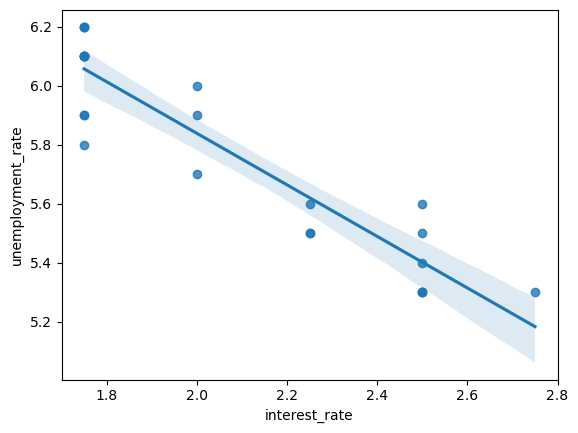

In [70]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

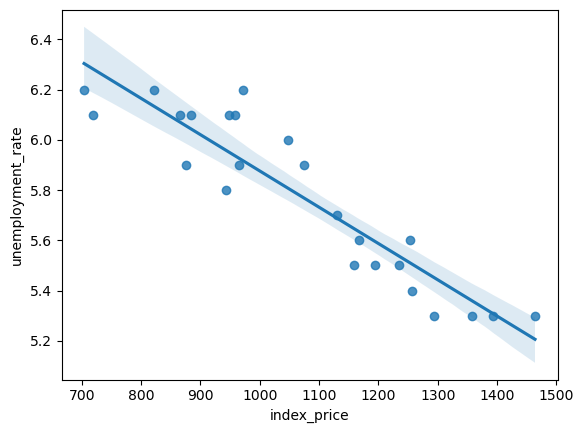

In [71]:
sns.regplot(x=df_index['index_price'],y=df_index['unemployment_rate'])

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [75]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [76]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [77]:
regression.fit(X=X_train,y=y_train)

LinearRegression()

### CROSS-VALIDATION

In [78]:
from sklearn.model_selection import cross_val_score
# This line uses 3-fold cross-validation to evaluate the model using negative MSE as the scoring metric.

# The model is trained and tested 3 times on different splits of the data.
# Splitting example (cv = 3):
# If you have 90 data points:
# Split 1: Train on 60, Test on 30
# Split 2: Train on a different 60, Test on a different 30
# Split 3: Train on another 60, Test on another 30
# So the model is evaluated 3 times on different data parts to get a reliable score and you will also get MSE for each split accordingly.

validation_score = cross_val_score(estimator=regression,X=X_train,y=y_train,scoring='neg_mean_squared_error',cv=3)
# Yes; So here-:
# The data split with the least MSE is considered the best split.
# Because neg_mean_squared_error is used, the split with the highest (least negative) score is selected, which means lowest actual MSE.

In [79]:
# cross_val_score measures the model’s performance using cross-validation by training and testing the model on different data splits.

# Simple words:
# It checks how well the model works on multiple train–test splits, not just one.

In [80]:
# (Scoring in `cross_val_score`)
# **Scoring** decides **how model performance is measured**.

# ### Most-used scoring metrics:

# #### 🔹 Classification
# Accuracy → "accuracy" → % of correct predictions
# Precision → "precision" → correctness of positive predictions
# Recall → "recall" → how many actual positives are correctly found
# F1-score → "f1" → balance of precision and recall

# #### 🔹 Regression
# * **R²** → `"r2"` → model fit quality
# * **MSE** → `"neg_mean_squared_error"` → squared error
# * **MAE** → `"neg_mean_absolute_error"` → absolute error

# ### 🔹 Meaning of `neg`:
# `neg` means **negative** value is used for error metrics because scikit-learn assumes
# **higher score = better model**.

# So:
# * Lower error → better model
# * Error is multiplied by **–1** → becomes **higher score**

# **Example:**
# MSE = 10 → score = –10
# MSE = 5 → score = –5 (better because –5 > –10)

# ### ✨ One-line summary:
# > `scoring` defines how performance is measured, and `neg` is used so that lower error becomes a higher score.

In [81]:
validation_score
# You get three different MSE on three different data splits as cv=3 but their actual values will be received on multiplying by "-1"

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [82]:
-1*np.mean(validation_score)

np.float64(5914.828180162388)

In [83]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [84]:
# predicition-:
y_pred = regression.predict(X_test)

In [85]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [86]:
# Performance Metrics-:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [87]:
mse,mae,rmse

(5793.762887712583, 59.93578152323558, np.float64(76.11677139574815))

In [88]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.8278978091457141

In [89]:
# adjusted R-squared-:
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.7131630152428567


### Assumptions

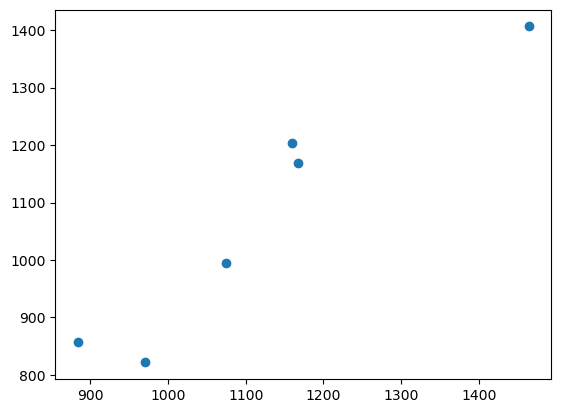

In [90]:
plt.scatter(y_test,y_pred)

If there is a linear relationship between y_test and y_pred then model has performed Well.

In [91]:
# residuals == errors
residuals = y_test - y_pred

In [92]:
# sns.displot() is used to visualize the distribution of a dataset — it can show:
# Histogram
# KDE (density curve)
# ECDF
# Combination of plots

# It helps understand data spread, skewness, peaks, and frequency distribution.
# It shows how values are distributed across a range

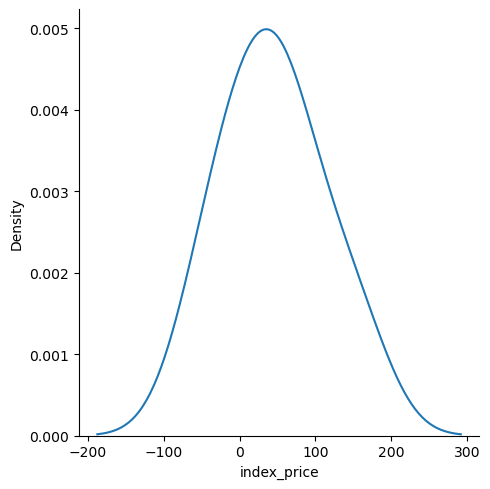

In [93]:
sns.displot(residuals,kind='kde')

In [94]:
# If sns.displot(residuals, kind='kde') shows a normal (bell-shaped) curve, it means:
# Errors are random
# Model assumptions are mostly satisfied
# Model fit is statistically good

# Important note:
# Normal residuals = model is valid,
# but you still must check MSE, R², accuracy, etc. for real performance.

# Normal residual distribution indicates a good model fit, but performance metrics must also be checked.

scatter plot w.r.t prediction and residuals-:

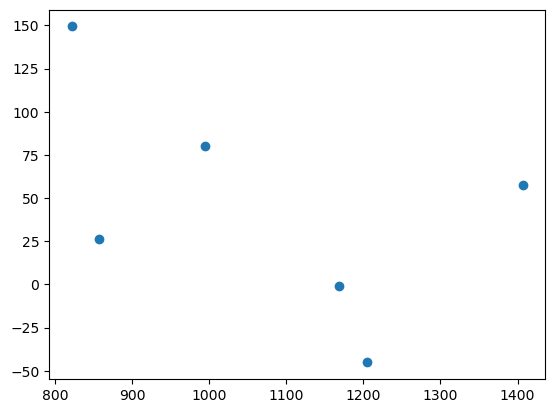

In [95]:
plt.scatter(y_pred,residuals)

In [96]:
# So; here the scatter plot w.r.t prediction and residuals is UNIFORMLY DISTRIBUTED.
# So; The model is good and assumptions are satisfied

In [97]:
# ✅ If residuals are randomly / uniformly scattered →
# The model is good and assumptions are satisfied.

# ❌ If residuals show a clear pattern →
# The model is badly fitted because it is missing patterns in the data.

# Meaning of “missing patterns”:
# The model is too simple and cannot learn the true relationship in the data
# (e.g., real relation is curved but model is a straight line).

# One-line summary:

# Random residuals = good model, patterned residuals = model missing real data patterns.

In [98]:
# OLS Multiple Linear Regression-:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()

In [99]:
model.summary()

c:\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Fri, 13 Feb 2026   Prob (F-statistic):                       0.754
Time:                        18:38:57   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [100]:
regression.coef_

array([  88.27275507, -116.25716066])

As u can see both OLS and Gradient Descent method are ALMOST giving same coeficient-: x1 and x2.
So; both models are prediciting poits with almost same EQUATION of BEST-FIT-LINE(B.F.L.)

Since; there are 2 independent features. 
So; there will be TOTAL 2 coefficients with 1 coefficient each for one feature.
So; best fit line will have total 2 coefficients/SLOPE's.